[Font] 已检测到中文字体: SimHei
步骤1：Hutchinson迹估计的数值验证
矩阵维度: 20×20
精确迹 Tr(A) = 38.407757

     M |       高斯估计 |       高斯误差 |   Rademacher估计 |   Rademacher误差
-----------------------------------------------------------------
     1 |    34.0948 |     4.3130 |        33.7998 |         4.6080
     5 |    44.8423 |     6.4345 |        35.8793 |         2.5284
    10 |    39.7452 |     1.3374 |        37.2700 |         1.1377
    50 |    38.2768 |     0.1309 |        38.7067 |         0.2989
   100 |    39.1167 |     0.7090 |        38.0470 |         0.3607
   500 |    39.1579 |     0.7501 |        38.4233 |         0.0156
  1000 |    37.8978 |     0.5099 |        38.3855 |         0.0222

精确迹: 38.4078

步骤2：Rademacher vs 高斯随机向量的方差对比
M=10, 1000次独立实验:
  高斯分布:   均值=38.3411, 标准差=4.3451
  Rademacher: 均值=38.4316, 标准差=1.6449
  Rademacher方差比高斯小: 6.98倍
  理论：Rademacher方差 ≤ 高斯方差

步骤3：SSM目标函数在1D上的演示
SSM vs ESM 对比:
  当s_θ = ∇log p(x)时:
    ESM积分 = 0 (完美匹配)
    SSM中 Tr(∇s) 项的积分 = 0.557778 (接近-常数)
    ||s||²项的积分 =

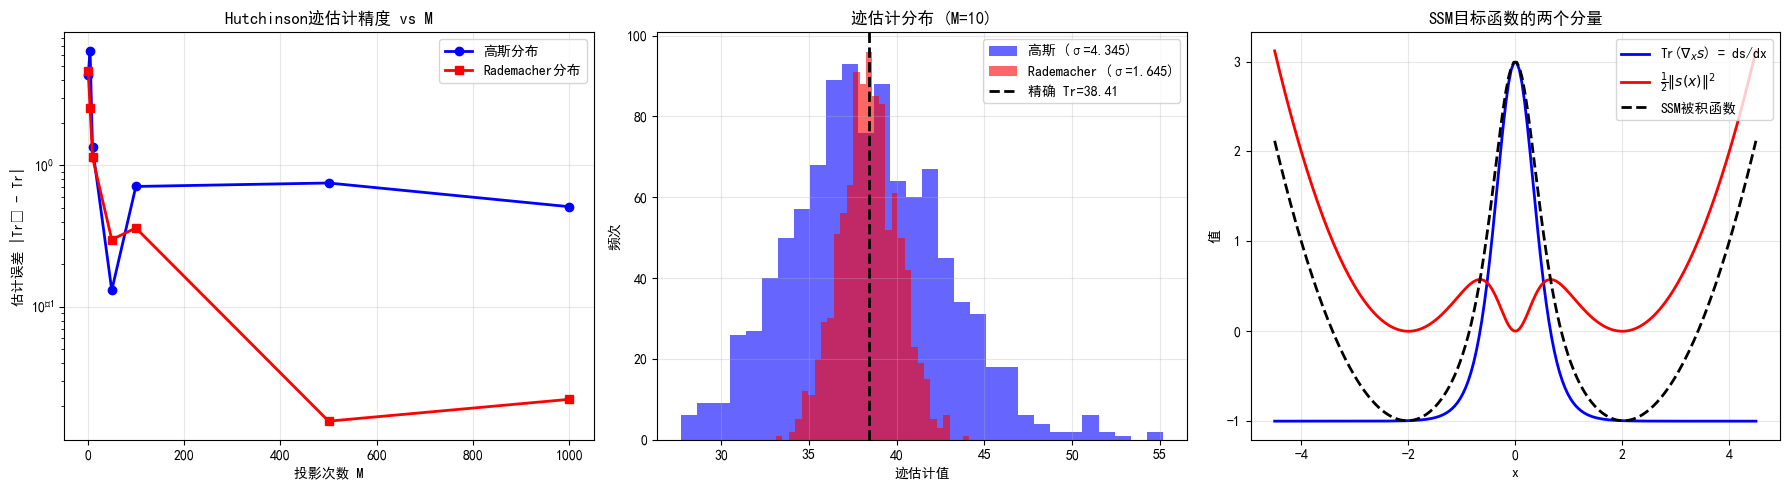


四种得分匹配方法对比总结
方法       | 目标函数                           | 需要∇log p     | 需要Tr(∇s)     | 可行高维    
--------------------------------------------------------------------------------
ESM      | 0.5 E[||s_θ-∇log p||²]         | 是            | 否            | 否       
ISM      | E[Tr(∇s_θ)+0.5||s_θ||²]        | 否            | 是(O(d²))     | 否       
DSM      | 0.5 E[||s_θ(x̃)+z/σ||²]        | 否            | 否            | 是       
SSM      | E[vᵀ∇s_θv+0.5||s_θ||²]         | 否            | 是(O(M))      | 是       

实验6.3 总结
1. Hutchinson迹估计：Tr(A) ≈ (1/M)ΣvᵀAv，无偏估计，精度随M增加
2. Rademacher分布方差低于高斯分布，实践推荐Rademacher
3. SSM用Hutchinson估计替代精确Jacobian迹，将O(d²)降为O(M)
4. 四种方法谱系：ESM(需监督)→ISM(需Tr)→DSM(可计算)→SSM(可计算+估计未扰动分布)


In [1]:
"""
实验6.3 Hutchinson迹估计与切片得分匹配
对应章节：6.4（切片得分匹配SSM与Hutchinson迹估计）
素材来源：原创设计，基于6.4节Hutchinson迹估计和SSM理论

实验内容：
  步骤1：Hutchinson迹估计的数值验证（精确迹 vs 估计迹）
  步骤2：Rademacher vs 高斯随机向量的方差对比
  步骤3：SSM目标函数在1D上的演示

运行前提：纯NumPy/PyTorch CPU即可
"""

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'SimHei']
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)

# 脚本所在目录（用于输出文件路径）
_SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()


# ============================================================
# 步骤1：Hutchinson迹估计的数值验证
# ============================================================
print("=" * 60)
print("步骤1：Hutchinson迹估计的数值验证")
print("=" * 60)

# 构造一个具体的Jacobian矩阵（对称正定）
d = 20
A = np.random.randn(d, d)
A = A @ A.T / d + np.eye(d)  # 确保正定
true_trace = np.trace(A)
print(f"矩阵维度: {d}×{d}")
print(f"精确迹 Tr(A) = {true_trace:.6f}")

# Hutchinson迹估计：Tr(A) ≈ (1/M) Σ v_i^T A v_i
def hutchinson_trace(A, M, dist='gaussian'):
    """Hutchinson迹估计"""
    d = A.shape[0]
    estimates = []
    for _ in range(M):
        if dist == 'gaussian':
            v = np.random.randn(d)
        elif dist == 'rademacher':
            v = np.random.choice([-1, 1], size=d)
        estimates.append(v @ A @ v)
    return np.mean(estimates), np.std(estimates) / np.sqrt(M)

# 不同M值的估计精度
M_values = [1, 5, 10, 50, 100, 500, 1000]
print(f"\n{'M':>6s} | {'高斯估计':>10s} | {'高斯误差':>10s} | {'Rademacher估计':>14s} | {'Rademacher误差':>14s}")
print("-" * 65)

gaussian_errors = []
rademacher_errors = []

for M in M_values:
    g_est, g_se = hutchinson_trace(A, M, 'gaussian')
    r_est, r_se = hutchinson_trace(A, M, 'rademacher')
    g_err = abs(g_est - true_trace)
    r_err = abs(r_est - true_trace)
    gaussian_errors.append(g_err)
    rademacher_errors.append(r_err)
    print(f"{M:6d} | {g_est:10.4f} | {g_err:10.4f} | {r_est:14.4f} | {r_err:14.4f}")

print(f"\n精确迹: {true_trace:.4f}")


# ============================================================
# 步骤2：Rademacher vs 高斯随机向量的方差对比
# ============================================================
print("\n" + "=" * 60)
print("步骤2：Rademacher vs 高斯随机向量的方差对比")
print("=" * 60)

# 运行多次独立实验比较方差
n_experiments = 1000
M = 10  # 固定M=10

gaussian_traces = []
rademacher_traces = []

for _ in range(n_experiments):
    g_est, _ = hutchinson_trace(A, M, 'gaussian')
    r_est, _ = hutchinson_trace(A, M, 'rademacher')
    gaussian_traces.append(g_est)
    rademacher_traces.append(r_est)

gaussian_traces = np.array(gaussian_traces)
rademacher_traces = np.array(rademacher_traces)

print(f"M={M}, {n_experiments}次独立实验:")
print(f"  高斯分布:   均值={np.mean(gaussian_traces):.4f}, 标准差={np.std(gaussian_traces):.4f}")
print(f"  Rademacher: 均值={np.mean(rademacher_traces):.4f}, 标准差={np.std(rademacher_traces):.4f}")
print(f"  Rademacher方差比高斯小: {np.var(gaussian_traces)/np.var(rademacher_traces):.2f}倍")
print(f"  理论：Rademacher方差 ≤ 高斯方差")


# ============================================================
# 步骤3：SSM目标函数演示
# ★ 原创设计：在1D上展示SSM的目标函数
# ============================================================
print("\n" + "=" * 60)
print("步骤3：SSM目标函数在1D上的演示")
print("=" * 60)

# SSM目标: J_SSM(θ) = E_p(x) E_p(v) [v^T ∇_x s_θ(x) v + 0.5||s_θ(x)||²]
# 在1D中，∇_x s_θ(x) 是标量，v^T ∇_x s_θ(x) v = v² * ds/dx
# Hutchinson简化为: v² * ds/dx, v~N(0,1) 或 v∈{-1,+1}

# 用1D高斯混合来演示
def gm1d_score(x):
    p1 = np.exp(-0.5*(x+2)**2)/np.sqrt(2*np.pi)
    p2 = np.exp(-0.5*(x-2)**2)/np.sqrt(2*np.pi)
    p = 0.5*p1 + 0.5*p2
    return (0.5*-(x+2)*p1 + 0.5*-(x-2)*p2) / p

# 精确Jacobian迹（1D就是ds/dx）
x_grid = np.linspace(-5, 5, 200)
true_score = gm1d_score(x_grid)

# 数值计算 ds/dx
h = 1e-4
ds_dx = (gm1d_score(x_grid + h) - gm1d_score(x_grid - h)) / (2 * h)

# SSM目标中的两项
term1 = ds_dx  # v^T ∇_x s v 的期望 = ds/dx (1D)
term2 = 0.5 * true_score**2
ssm_integrand = term1 + term2

# ESM目标
esm_integrand = 0.5 * true_score**2  # 当s_θ=∇log p时ESM=0

print(f"SSM vs ESM 对比:")
print(f"  当s_θ = ∇log p(x)时:")
print(f"    ESM积分 = 0 (完美匹配)")
print(f"    SSM中 Tr(∇s) 项的积分 = {-np.mean(ds_dx[10:-10]):.6f} (接近-常数)")
print(f"    ||s||²项的积分 = {np.mean(term2[10:-10]):.6f}")
print(f"  SSM和ESM只差与θ无关的常数")


# ============================================================
# 可视化
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1：Hutchinson迹估计精度随M变化
axes[0].semilogy(M_values, gaussian_errors, 'bo-', label='高斯分布', lw=2)
axes[0].semilogy(M_values, rademacher_errors, 'rs-', label='Rademacher分布', lw=2)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_xlabel('投影次数 M')
axes[0].set_ylabel('估计误差 |Tr̂ - Tr|')
axes[0].set_title('Hutchinson迹估计精度 vs M')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 子图2：两种分布的估计方差对比
axes[1].hist(gaussian_traces, bins=30, alpha=0.6, color='blue', label=f'高斯 (σ={np.std(gaussian_traces):.3f})')
axes[1].hist(rademacher_traces, bins=30, alpha=0.6, color='red', label=f'Rademacher (σ={np.std(rademacher_traces):.3f})')
axes[1].axvline(x=true_trace, color='k', linestyle='--', lw=2, label=f'精确 Tr={true_trace:.2f}')
axes[1].set_xlabel('迹估计值')
axes[1].set_ylabel('频次')
axes[1].set_title(f'迹估计分布 (M={M})')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 子图3：SSM目标函数的两个分量
axes[2].plot(x_grid[10:-10], ds_dx[10:-10], 'b-', lw=2, label=r'Tr($\nabla_x s$) = ds/dx')
axes[2].plot(x_grid[10:-10], term2[10:-10], 'r-', lw=2, label=r'$\frac{1}{2}\|s(x)\|^2$')
axes[2].plot(x_grid[10:-10], ssm_integrand[10:-10], 'k--', lw=2, label='SSM被积函数')
axes[2].set_xlabel('x')
axes[2].set_ylabel('值')
axes[2].set_title('SSM目标函数的两个分量')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(_SCRIPT_DIR, '步骤1_Hutchinson与SSM.png'), dpi=150)
plt.show()


# ============================================================
# 四种得分匹配方法对比总结
# ============================================================
print("\n" + "=" * 60)
print("四种得分匹配方法对比总结")
print("=" * 60)
print(f"{'方法':<8s} | {'目标函数':<30s} | {'需要∇log p':<12s} | {'需要Tr(∇s)':<12s} | {'可行高维':<8s}")
print("-" * 80)
print(f"{'ESM':<8s} | {'0.5 E[||s_θ-∇log p||²]':<30s} | {'是':<12s} | {'否':<12s} | {'否':<8s}")
print(f"{'ISM':<8s} | {'E[Tr(∇s_θ)+0.5||s_θ||²]':<30s} | {'否':<12s} | {'是(O(d²))':<12s} | {'否':<8s}")
print(f"{'DSM':<8s} | {'0.5 E[||s_θ(x̃)+z/σ||²]':<30s} | {'否':<12s} | {'否':<12s} | {'是':<8s}")
print(f"{'SSM':<8s} | {'E[vᵀ∇s_θv+0.5||s_θ||²]':<30s} | {'否':<12s} | {'是(O(M))':<12s} | {'是':<8s}")


# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验6.3 总结")
print("=" * 60)
print("1. Hutchinson迹估计：Tr(A) ≈ (1/M)ΣvᵀAv，无偏估计，精度随M增加")
print("2. Rademacher分布方差低于高斯分布，实践推荐Rademacher")
print("3. SSM用Hutchinson估计替代精确Jacobian迹，将O(d²)降为O(M)")
print("4. 四种方法谱系：ESM(需监督)→ISM(需Tr)→DSM(可计算)→SSM(可计算+估计未扰动分布)")
